In [1]:
# getting necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)}) #white background, RBGA: black with 0 alpha (fully transparent)

In [2]:
#get the data
temp = pd.read_csv("C:\\Users\\miyoh\\UofT_DSI_Miyo\\Visualization\\en_climate_monthly_ON_6158350_1840-2006_P1M.csv")
#Data retrieve from here: https://climate.weather.gc.ca/climate_data/monthly_data_e.html?hlyRange=1953-01-01%7C1969-05-31&dlyRange=1840-03-01%7C2017-04-27&mlyRange=1840-01-01%7C2006-12-01&StationID=5051&Prov=ON&urlExtension=_e.html&searchType=stnProv&optLimit=yearRange&StartYear=1998&EndYear=2025&selRowPerPage=25&Line=477&Month=4&Day=21&lstProvince=ON&timeframe=3&Year=1998

In [3]:
temp

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Mean Max Temp (°C),Mean Max Temp Flag,Mean Min Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow Grnd Last Day (cm),Snow Grnd Last Day Flag,Dir of Max Gust (10's deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-79.4,43.67,TORONTO,6158350,1840-01,1840,1,NaN,M,NaN,...,NaN,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN
1,-79.4,43.67,TORONTO,6158350,1840-02,1840,2,NaN,M,NaN,...,NaN,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN
2,-79.4,43.67,TORONTO,6158350,1840-03,1840,3,5.2,NaN,-2.9,...,NaN,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN
3,-79.4,43.67,TORONTO,6158350,1840-04,1840,4,11.1,NaN,2.3,...,NaN,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN
4,-79.4,43.67,TORONTO,6158350,1840-05,1840,5,17.2,NaN,7.6,...,0.0,NaN,105.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999,-79.4,43.67,TORONTO,6158350,2006-08,2006,8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000,-79.4,43.67,TORONTO,6158350,2006-09,2006,9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001,-79.4,43.67,TORONTO,6158350,2006-10,2006,10,NaN,NaN,NaN,...,0.0,T,95.3,I,0.0,NaN,NaN,NaN,NaN,NaN
2002,-79.4,43.67,TORONTO,6158350,2006-11,2006,11,NaN,NaN,NaN,...,0.0,T,98.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN


In [4]:
# we define a dictionnary with months that we'll use later
month_dict = {1: 'January',
              2: 'February',
              3: 'March',
              4: 'April',
              5: 'May',
              6: 'June',
              7: 'July',
              8: 'August',
              9: 'September',
              10: 'October',
              11: 'November',
              12: 'December'}

In [5]:
# we create a 'month' column
temp['Month'] = temp['Month'].map(month_dict)

In [6]:
# we generate a pd.Serie with the mean temperature for each month (used later for colors in the FacetGrid plot), and we create a new column in temp dataframe
month_mean_serie = temp.groupby('Month')['Mean Temp (°C)'].mean()
temp['mean_month'] = temp['Month'].map(month_mean_serie)

In [7]:
temp['Mean Temp (°C)']

0        NaN
1        NaN
2        1.2
3        6.7
4       12.4
        ... 
1999     NaN
2000     NaN
2001     NaN
2002     NaN
2003     NaN
Name: Mean Temp (°C), Length: 2004, dtype: float64

In [8]:
temp['mean_month']

0       -4.803067
1       -4.732515
2       -0.350610
3        6.382927
4       12.602439
          ...    
1999    20.244172
2000    16.123926
2001     9.656442
2002     3.600000
2003    -2.251534
Name: mean_month, Length: 2004, dtype: float64

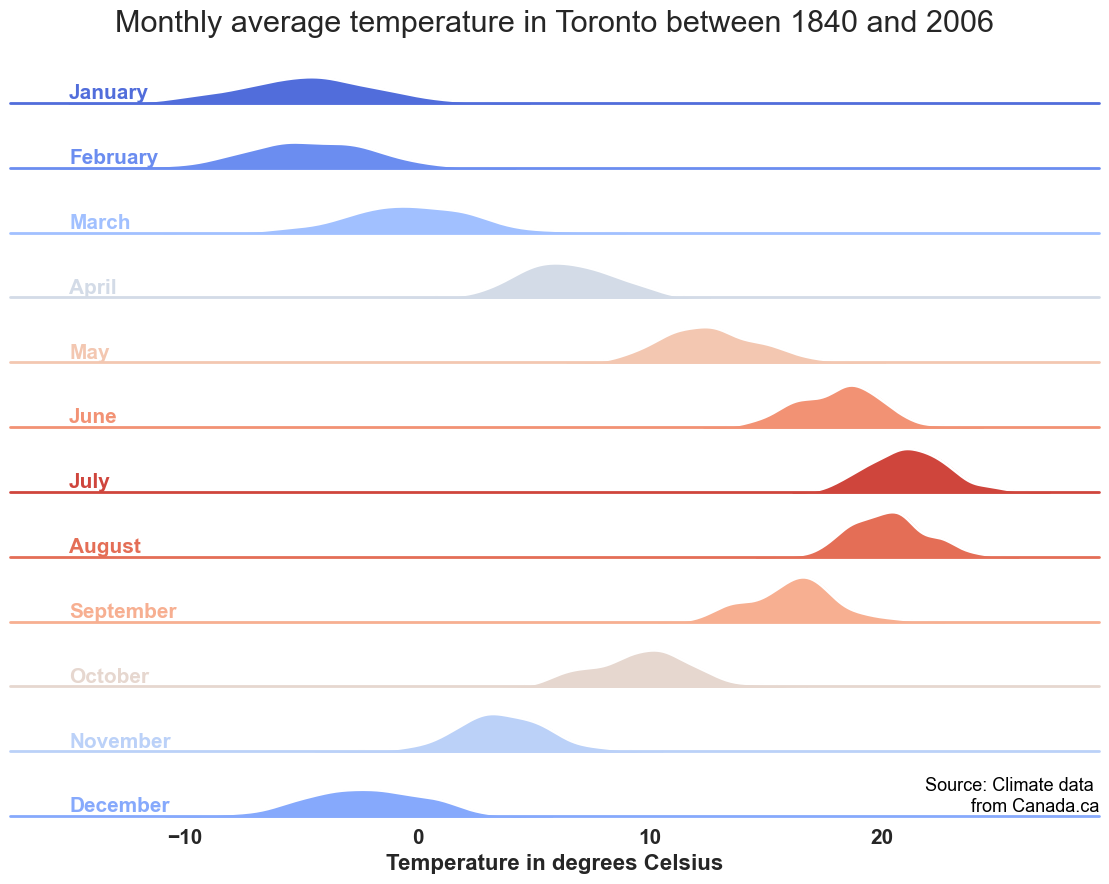

In [17]:
# we generate a color palette with Seaborn.color_palette()
pal = sns.color_palette(palette='coolwarm', n_colors=12)

#the 'hue' argument is the one that will be represented by colors with 'palette'
g = sns.FacetGrid(temp, row='Month', hue='mean_month', aspect=15, height=0.75, palette=pal)

# then we add the densities kdeplots for each month
# KDE (kernel density estimate) plot is a method for visualizing the 
# distribution of observations in a dataset, so it represents the data
# using a continuous probability density curve
g.map(sns.kdeplot, 'Mean Temp (°C)',
      bw_adjust=1, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)

# here we add a white line that represents the contour of each kdeplot
g.map(sns.kdeplot, 'Mean Temp (°C)', 
      bw_adjust=1, clip_on=False, 
      color="w", lw=2)

# here we add a horizontal line for each plot
g.map(plt.axhline, y=0,
      lw=2, clip_on=False)

# we loop over the FacetGrid figure axes (g.axes.flat) and add the month as text with the right color
# notice how ax.lines[-1].get_color() enables you to access the last line's color in each matplotlib.Axes
for i, ax in enumerate(g.axes.flat):
    ax.text(-15, 0.02, month_dict[i+1],
            fontweight='bold', fontsize=15,
            color=ax.lines[-1].get_color())
    
 # we use matplotlib.Figure.subplots_adjust() function to get the subplots to overlap
g.fig.subplots_adjust(hspace=-1)

# eventually we remove axes titles, yticks and spines, and ylabels
g.set_titles("")
g.set(yticks = [])
g.set(ylabel='')
g.despine(bottom=True, left=True)

plt.setp(ax.get_xticklabels(), fontsize=15, fontweight='bold')
plt.xlabel('Temperature in degrees Celsius', fontweight='bold', fontsize=16)
g.fig.suptitle('Monthly average temperature in Toronto between 1840 and 2006',
               fontsize=22,
               fontweight=20)


ax= plt.gca() #get current axes
# Get axis limits
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
# Add text at bottom right
ax.text(x_max, y_min, "Source: Climate data \n from Canada.ca", ha='right', va='bottom', fontsize=13, color='black')

g.fig.tight_layout()
plt.show()   